In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

''' 
pour chaque méthodes:
- présentation de la méthode 
- présentation des hyperparamètres
- Discussion sur les choix d'implémentation
- Discussion sur l'influence des paramètres sur les résultats
- Analyse critique des résultats
'''

In [29]:
Dataset = pd.read_csv("AirQualityUCI.csv", sep=';', decimal=',')
# Corriger le format de l'heure
Dataset['Time'] = Dataset['Time'].str.replace('.', ':', regex=False)

# Créer la variable datetime
Dataset['Datetime'] = pd.to_datetime(
    Dataset['Date'] + ' ' + Dataset['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Trier les données
Dataset = Dataset.sort_values('Datetime')

Dataset = Dataset.replace(-200, np.nan)
# Supprimer les colonnes vides
Dataset = Dataset.drop(columns=["Unnamed: 15", "Unnamed: 16","NMHC(GT)"])
print(Dataset.info())

Dataset = Dataset.dropna()
print(Dataset.shape)

# Variables cibles
Y = Dataset[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']] #CO(GT) : Carbon Monoxide, C6H6(GT) : Benzene, NOx(GT) : Nitrogen Oxides, NO2(GT) : Nitrogen Dioxide

# Variables explicatives
X = Dataset.drop(columns=['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'Date', 'Time', 'Datetime']) #tous le reste

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   object        
 1   Time           9357 non-null   object        
 2   CO(GT)         7674 non-null   float64       
 3   PT08.S1(CO)    8991 non-null   float64       
 4   C6H6(GT)       8991 non-null   float64       
 5   PT08.S2(NMHC)  8991 non-null   float64       
 6   NOx(GT)        7718 non-null   float64       
 7   PT08.S3(NOx)   8991 non-null   float64       
 8   NO2(GT)        7715 non-null   float64       
 9   PT08.S4(NO2)   8991 non-null   float64       
 10  PT08.S5(O3)    8991 non-null   float64       
 11  T              8991 non-null   float64       
 12  RH             8991 non-null   float64       
 13  AH             8991 non-null   float64       
 14  Datetime       9357 non-null   datetime64[ns]
dtypes: datetime64[ns](1),

In [30]:
Dataset.shape

(6941, 15)

In [ ]:
#separation des donnees entrainement et test

train_size = int(len(Dataset) * 0.8)

dates_train = Dataset['Datetime'].iloc[:train_size]
dates_test = Dataset['Datetime'].iloc[train_size:]

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

Y_train = Y.iloc[:train_size]
Y_test = Y.iloc[train_size:]
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(5552, 8) (1389, 8)
(5552, 4) (1389, 4)


In [56]:
#standardisation des donnees
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [57]:
reg = linear_model.Ridge(alpha= 0.0)

In [58]:
reg.fit(X_train, Y_train)

,alpha,0.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [59]:
Y_pred_reg = reg.predict(X_test)

In [64]:
targets = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

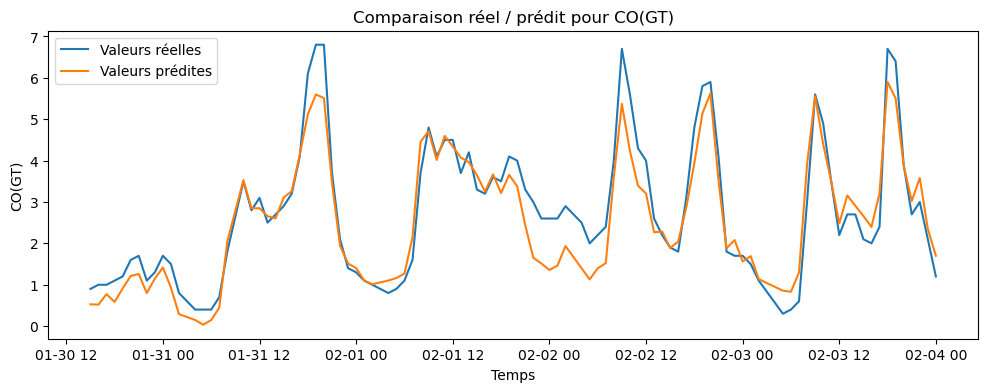

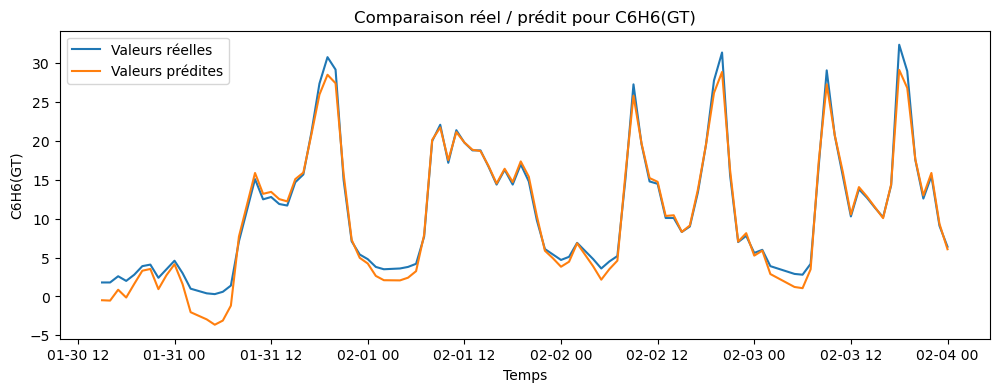

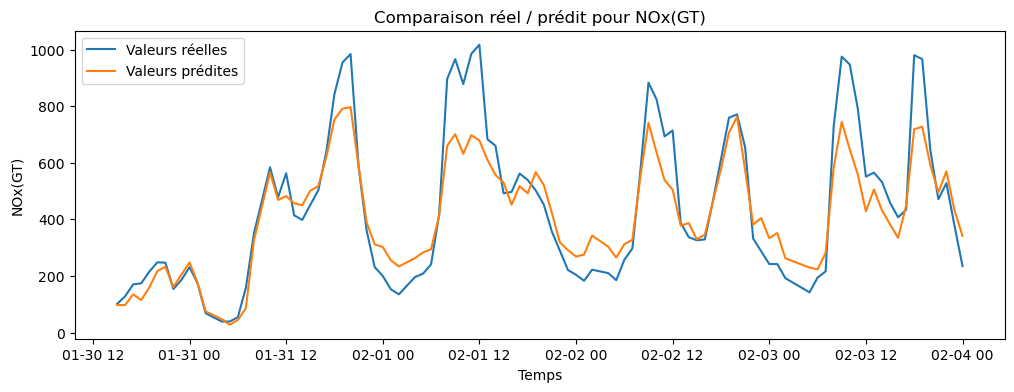

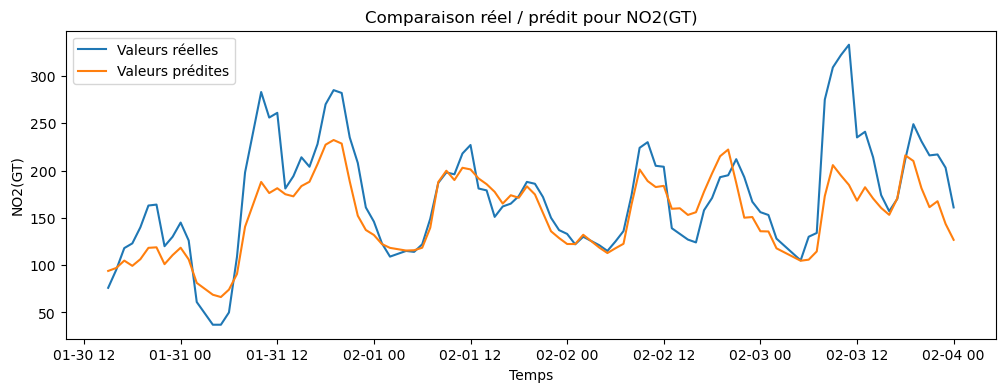

In [67]:
for i, target in enumerate(targets):
    plt.figure(figsize=(12, 4))
    
    plt.plot(dates_test[:100],Y_test[target].values[:100], label="Valeurs réelles")
    plt.plot(dates_test[:100],Y_pred_reg[:100, i], label="Valeurs prédites")
    
    plt.title(f"Comparaison réel / prédit pour {target}")
    plt.xlabel("Temps")
    plt.ylabel(target)
    plt.legend()
    
    plt.show()

In [73]:
print(mean_squared_error(Y_pred_reg,Y_test.values))

1840.36287088658
